# Notebook 07 — Comparação entre Pipelines
## Pipeline 1 (Mallows + PL) vs Pipeline 2 (Pipeline 1 + Monte Carlo + RPS)
## Projeto Fórmula 1 — TCC

Este notebook compara os resultados dos dois pipelines, mostrando
o que cada um acrescenta e como eles se complementam.

### Estrutura
1. Configuração e carregamento
2. Comparação das métricas pontuais
3. O que o Pipeline 2 acrescenta — RPS vs Top-N
4. Visualizações comparativas
5. Conclusão


## 1. Configuração

In [13]:
import sys, os, pickle
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

PROJECT_ROOT  = r'C:/Users/guiga/OneDrive/Documentos/Projeto-Formula1'
PIPELINE1_DIR = os.path.join(PROJECT_ROOT, 'src', 'pipeline_mallows_plackett_luce')
PIPELINE2_DIR = os.path.join(PROJECT_ROOT, 'src', 'pipeline_score_rules')

sys.path.insert(0, PROJECT_ROOT)

from src.evaluation.evaluation_metrics import season_summary
from src.pipeline_score_rules.scoring_rules       import rps_season_summary
from src.pipeline_mallows_plackett_luce.visualization_plots import TEAM_COLORS, CLUSTER_COLORS

# Carregar Pipeline 1
with open(os.path.join(PIPELINE1_DIR, 'outputs', 'nb_data.pkl'), 'rb') as f:
    d1 = pickle.load(f)

# Carregar Pipeline 2
with open(os.path.join(PIPELINE2_DIR, 'outputs', 'nb_data_p2.pkl'), 'rb') as f:
    d2 = pickle.load(f)

# Pipeline 1
val_evals_p1  = d1['val_evals']
test_evals_p1 = d1['test_evals']
val_sum_p1    = season_summary(val_evals_p1,  2023)
test_sum_p1   = season_summary(test_evals_p1, 2024)

# Pipeline 2
val_evals_p2  = d2['val_evals']
test_evals_p2 = d2['test_evals']
val_sum_p2    = season_summary(val_evals_p2,  2023)
test_sum_p2   = season_summary(test_evals_p2, 2024)
val_rps_sum   = d2['val_rps_summary']
test_rps_sum  = d2['test_rps_summary']
val_rps       = d2['val_rps']
test_rps      = d2['test_rps']

print("Dados dos dois pipelines carregados.")


Dados dos dois pipelines carregados.


## 2. Comparação das Métricas Pontuais

As métricas pontuais (Top-3, Top-5, Kendall τ) devem ser **idênticas**
entre os dois pipelines, pois o Pipeline 2 reutiliza integralmente
a lógica de previsão do Pipeline 1. O Monte Carlo não altera a previsão
pontual — ele apenas adiciona a camada probabilística.

Qualquer diferença aqui indicaria um bug de implementação.


In [14]:
print(f"{'Métrica':25s} {'P1 Val':>10} {'P2 Val':>10} {'P1 Test':>10} {'P2 Test':>10}")
print("-" * 68)
print(f"{'Top-3 Accuracy':25s} "
      f"{val_sum_p1.mean_top3:>10.3f} {val_sum_p2.mean_top3:>10.3f} "
      f"{test_sum_p1.mean_top3:>10.3f} {test_sum_p2.mean_top3:>10.3f}")
print(f"{'Top-5 Accuracy':25s} "
      f"{val_sum_p1.mean_top5:>10.3f} {val_sum_p2.mean_top5:>10.3f} "
      f"{test_sum_p1.mean_top5:>10.3f} {test_sum_p2.mean_top5:>10.3f}")
print(f"{'Kendall Tau':25s} "
      f"{val_sum_p1.mean_kendall:>10.3f} {val_sum_p2.mean_kendall:>10.3f} "
      f"{test_sum_p1.mean_kendall:>10.3f} {test_sum_p2.mean_kendall:>10.3f}")
print("-" * 68)
print("Diferença máxima (deve ser ~0):",
      max(abs(val_sum_p1.mean_top3 - val_sum_p2.mean_top3),
          abs(test_sum_p1.mean_top3 - test_sum_p2.mean_top3)))


Métrica                       P1 Val     P2 Val    P1 Test    P2 Test
--------------------------------------------------------------------
Top-3 Accuracy                 0.515      0.515      0.500      0.500
Top-5 Accuracy                 0.618      0.618      0.583      0.583
Kendall Tau                    0.422      0.422      0.408      0.408
--------------------------------------------------------------------
Diferença máxima (deve ser ~0): 0.0


## 3. O que o Pipeline 2 Acrescenta

O Pipeline 2 não substitui o Pipeline 1 — ele o **complementa** adicionando
uma dimensão probabilística. A tabela abaixo mostra as métricas exclusivas
do Pipeline 2:


In [15]:
print(f"{'Métrica':30s} {'Validação 2023':>16} {'Teste 2024':>14}")
print("-" * 62)
print(f"{'RPS Modelo':30s} {val_rps_sum.mean_rps_model:>16.4f} "
      f"{test_rps_sum.mean_rps_model:>14.4f}")
print(f"{'RPS Baseline (uniforme)':30s} {val_rps_sum.mean_rps_baseline:>16.4f} "
      f"{test_rps_sum.mean_rps_baseline:>14.4f}")
print(f"{'Ganho médio':30s} {val_rps_sum.mean_gain:>16.4f} "
      f"{test_rps_sum.mean_gain:>14.4f}")

pct_val  = val_rps_sum.mean_gain  / val_rps_sum.mean_rps_baseline  * 100
pct_test = test_rps_sum.mean_gain / test_rps_sum.mean_rps_baseline * 100
print(f"{'Melhoria sobre baseline (%)':30s} {pct_val:>15.1f}% {pct_test:>13.1f}%")

all_rps = val_rps + test_rps
n_positivo = sum(1 for r in all_rps if r.gain > 0)
print(f"\nCorridas com ganho positivo: {n_positivo}/{len(all_rps)} "
      f"({n_positivo/len(all_rps)*100:.1f}%)")


Métrica                          Validação 2023     Teste 2024
--------------------------------------------------------------
RPS Modelo                               0.0886         0.0921
RPS Baseline (uniforme)                  0.1313         0.1313
Ganho médio                              0.0427         0.0393
Melhoria sobre baseline (%)               32.5%          29.9%

Corridas com ganho positivo: 45/46 (97.8%)


## 4. Visualizações Comparativas

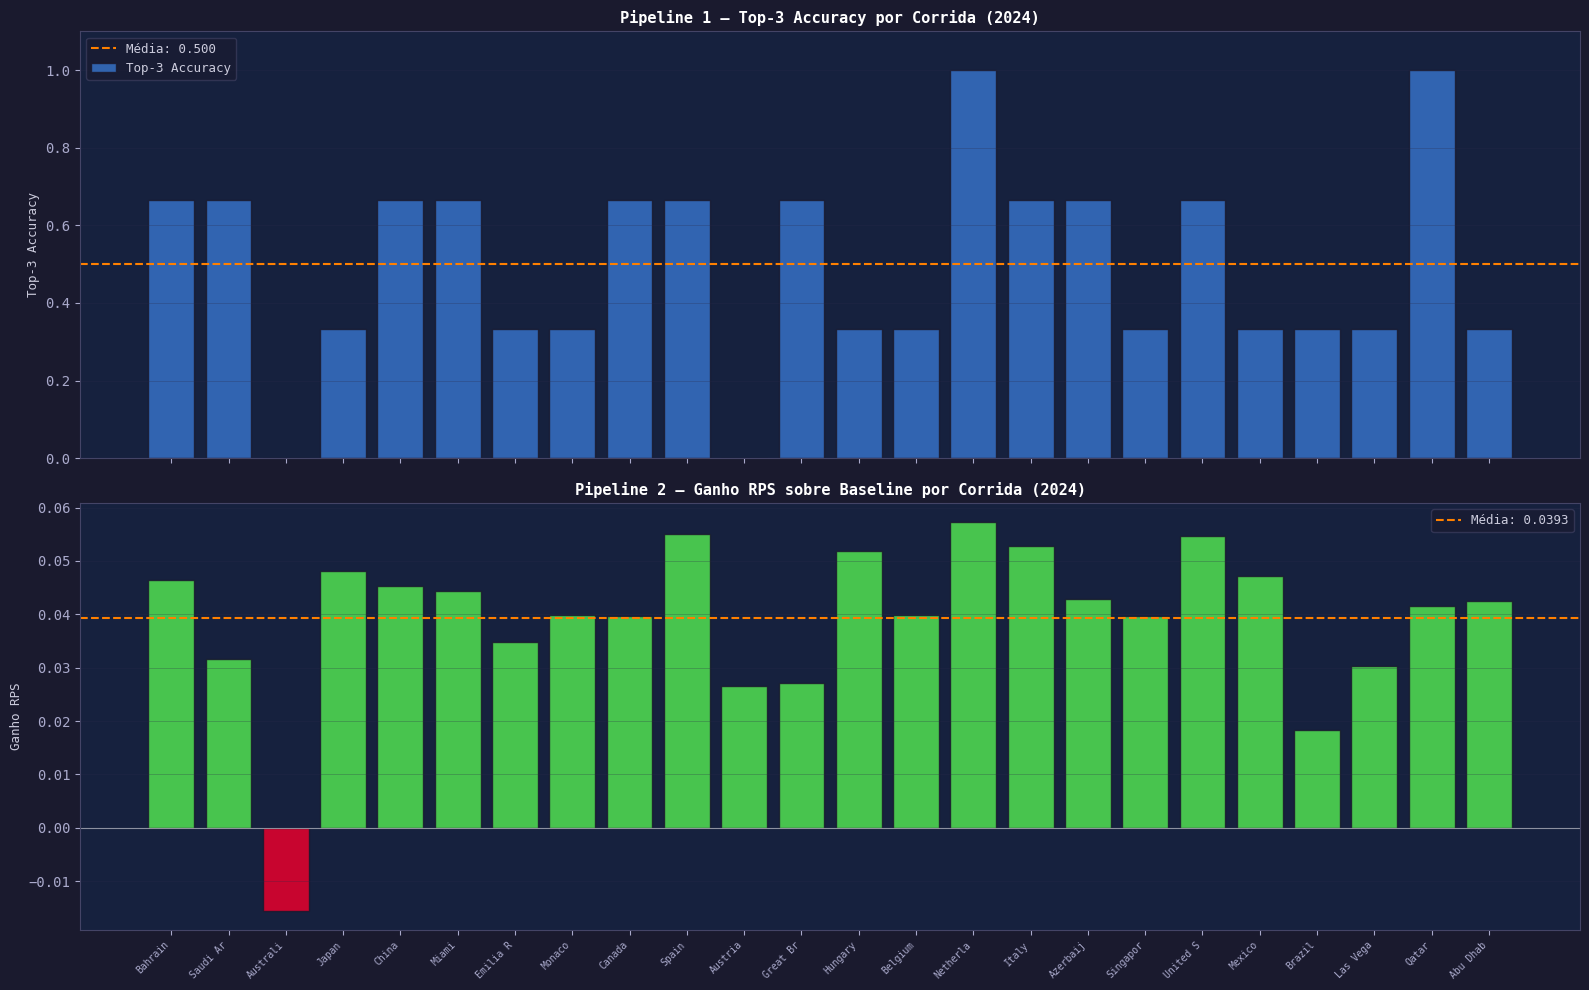

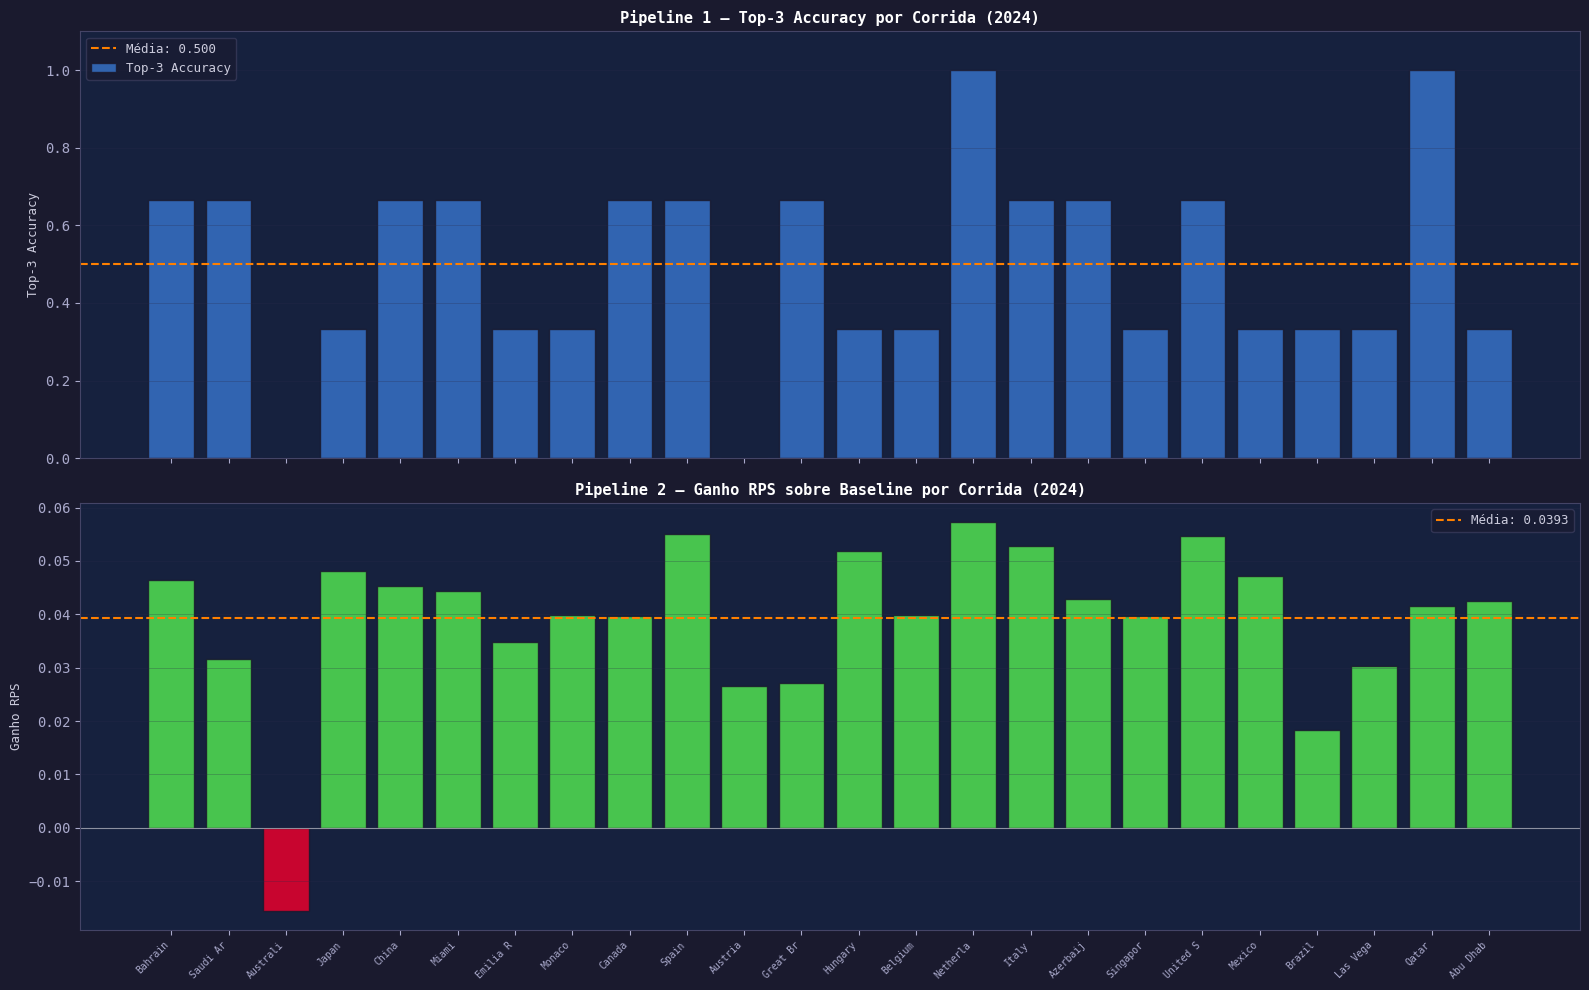

In [16]:
# Comparação visual: Top-3 vs RPS por corrida em 2024
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.patch.set_facecolor('#1a1a2e')

races = [e.race[:8] for e in test_evals_p1]
x     = range(len(races))

# Painel superior — Top-3 Accuracy (Pipeline 1)
top3  = [e.top3_acc for e in test_evals_p1]
axes[0].bar(x, top3, color='#3671C6', alpha=0.85,
            edgecolor='#1a1a2e', label='Top-3 Accuracy')
axes[0].axhline(y=np.mean(top3), color='#FF8000', linewidth=1.5,
                linestyle='--', label=f'Média: {np.mean(top3):.3f}')
axes[0].set_title('Pipeline 1 — Top-3 Accuracy por Corrida (2024)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Top-3 Accuracy', fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].legend(fontsize=9, framealpha=0.6)

# Painel inferior — Ganho RPS (Pipeline 2)
gains  = [r.gain for r in test_rps]
colors = ['#52E252' if g > 0 else '#E8002D' for g in gains]
axes[1].bar(x, gains, color=colors, alpha=0.85, edgecolor='#1a1a2e')
axes[1].axhline(y=0, color='#ffffff', linewidth=0.8, alpha=0.5)
axes[1].axhline(y=np.mean(gains), color='#FF8000', linewidth=1.5,
                linestyle='--', label=f'Média: {np.mean(gains):.4f}')
axes[1].set_title('Pipeline 2 — Ganho RPS sobre Baseline por Corrida (2024)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Ganho RPS', fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].legend(fontsize=9, framealpha=0.6)

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(races, rotation=45, ha='right', fontsize=7)

plt.tight_layout()
display(fig)


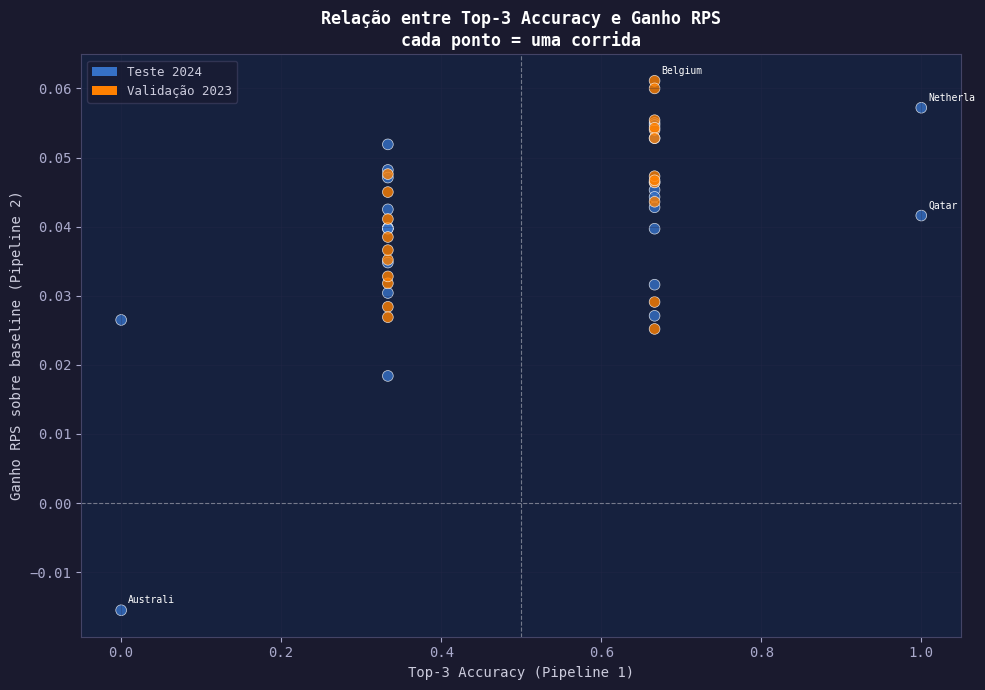

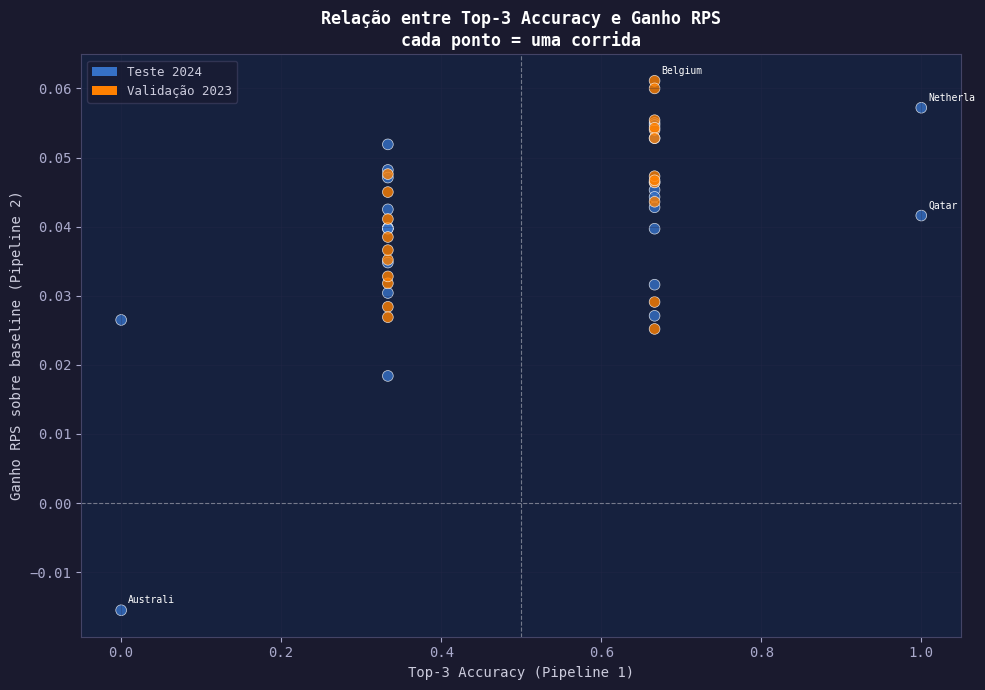

In [17]:
# Scatter: Top-3 Accuracy vs Ganho RPS (cada ponto = uma corrida)
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#1a1a2e')

all_top3  = [e.top3_acc for e in test_evals_p1] + [e.top3_acc for e in val_evals_p1]
all_gains = [r.gain for r in test_rps] + [r.gain for r in val_rps]
all_races = [e.race for e in test_evals_p1] + [e.race for e in val_evals_p1]
colors_sc = ['#3671C6'] * len(test_evals_p1) + ['#FF8000'] * len(val_evals_p1)

ax.scatter(all_top3, all_gains, c=colors_sc, alpha=0.8, s=60, edgecolors='white', linewidth=0.5)

# Anotar pontos extremos
for t, g, r, c in zip(all_top3, all_gains, all_races, colors_sc):
    if g < -0.005 or t == 1.0 or g > 0.06:
        ax.annotate(r[:8], xy=(t, g), xytext=(5, 5),
                   textcoords='offset points', fontsize=7, color='white')

ax.axhline(y=0, color='#ffffff', linewidth=0.8, alpha=0.4, linestyle='--')
ax.axvline(x=0.5, color='#ffffff', linewidth=0.8, alpha=0.4, linestyle='--')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3671C6', label='Teste 2024'),
    Patch(facecolor='#FF8000', label='Validação 2023'),
]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.6)

ax.set_xlabel('Top-3 Accuracy (Pipeline 1)', fontsize=10)
ax.set_ylabel('Ganho RPS sobre baseline (Pipeline 2)', fontsize=10)
ax.set_title('Relação entre Top-3 Accuracy e Ganho RPS\n'
             'cada ponto = uma corrida', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
display(fig)


### Interpretação do scatter

O gráfico mostra a relação entre as duas métricas corrida a corrida.

- **Quadrante superior direito** (Top-3 alto, ganho RPS alto) → corridas
  onde o modelo foi excelente em ambas as dimensões.
- **Quadrante inferior esquerdo** (Top-3 baixo, ganho baixo) → corridas
  difíceis para o modelo — geralmente envolvem DNFs ou resultados atípicos.
- **Dispersão** → as duas métricas não são sempre consistentes. Uma corrida
  pode ter Top-3 baixo mas bom RPS (errou o pódio mas estava bem calibrado),
  ou Top-3 alto mas RPS fraco (acertou o pódio por acidente, com pouca certeza).


## 5. Conclusão — O que cada pipeline entrega

| Aspecto | Pipeline 1 | Pipeline 2 |
|---|---|---|
| **Tipo de previsão** | Pontual (ranking ordenado) | Probabilística (vetor de P) |
| **Métricas** | Top-3, Top-5, Kendall τ | + RPS |
| **Pergunta respondida** | Quem vai vencer? | Com que certeza? |
| **Útil para** | Previsão direta de resultado | Calibração e confiança |
| **Vantagem** | Simples e interpretável | Honesto sobre incerteza |

### Os dois pipelines são complementares

O Pipeline 1 diz **o que** o modelo acha que vai acontecer.
O Pipeline 2 diz **o quanto** o modelo tem certeza disso.

Juntos, eles formam um sistema completo de previsão — onde você não só
recebe uma previsão, mas também sabe o grau de confiança nessa previsão.
Isso é especialmente valioso nas corridas onde o modelo tem baixa certeza
(distribuição mais espalhada no vetor), sinalizando que o resultado é
genuinamente imprevisível.
